Sample images and labels (continuous labels for regression):
Image shape: (50, 50), Label: 1.0


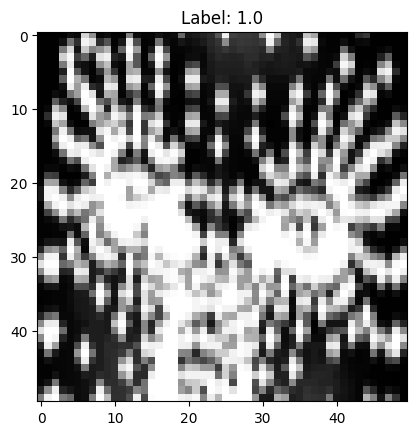

Image shape: (50, 50), Label: 10.0


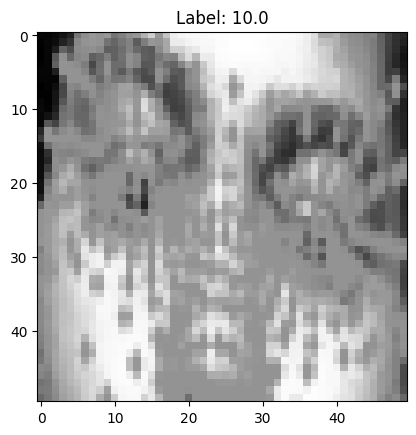

Image shape: (50, 50), Label: 100.0


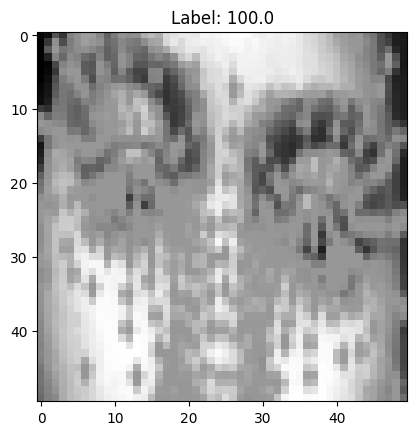

Image shape: (50, 50), Label: 1000.0


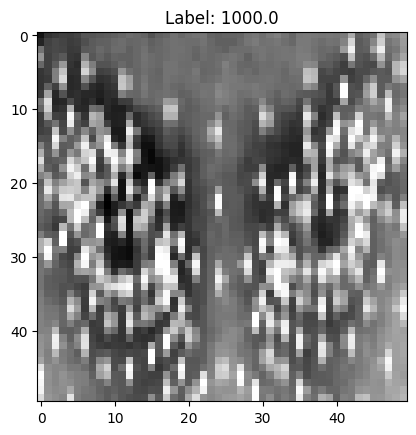

Image shape: (50, 50), Label: 1001.0


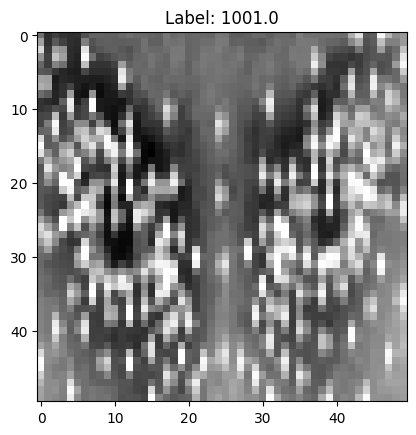

Linear Regression Mean Squared Error: 55366.15208886936
R² Score: 0.7843862899702174
Epoch 1, MSE: 55366.15208886936, R²: 0.7843862899702174


In [ ]:
import os
import cv2
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Function to load images and continuous labels (for regression)
def load_images_from_folder(folder):
    images = []
    labels = []
    
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        
        # Ensure the path is a file and not a directory
        if os.path.isfile(img_path):
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Load image in grayscale
            img = cv2.resize(img, (50, 50))  # Resize to (50x50)
            img = img / 255.0  # Normalize pixel values
            
            # Assume the filename has continuous values as labels (for regression)
            # Example filename: 'img_12.5.png' where 12.5 is the label
            label = float(filename.split('_')[1].split('.')[0])  # Extract continuous label
            
            images.append(img)
            labels.append(label)
    
    return np.array(images), np.array(labels)

# Load images and labels
X, y = load_images_from_folder('eye_img')

# Print a few samples to verify loading and preprocessing
print("Sample images and labels (continuous labels for regression):")
for i in range(min(5, len(X))):  # Print up to 5 samples
    print(f"Image shape: {X[i].shape}, Label: {y[i]}")
    plt.imshow(X[i], cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.show()

# Reshape the data for Linear Regression (flatten images into 1D vectors)
X_flat = X.reshape(X.shape[0], -1)  # Flatten each image (50x50) to a 1D vector of 2500 features

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_flat, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on the test set
y_pred = lr_model.predict(X_test)

# Evaluate the model using Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Linear Regression Mean Squared Error: {mse}")

# Evaluate the model using R² Score
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2}")

# Compute MSE and R² score over multiple epochs (iterations)
epochs = 10
mse_values = []
r2_values = []
for epoch in range(1, epochs + 1):
    # Fit the model (simulate the training over multiple epochs)
    lr_model.fit(X_train, y_train)
    
    # Predict and calculate MSE and R² for the current epoch
    y_pred_epoch = lr_model.predict(X_test)
    mse_epoch = mean_squared_error(y_test, y_pred_epoch)
    r2_epoch = r2_score(y_test, y_pred_epoch)
    
    mse_values.append(mse_epoch)
    r2_values.append(r2_epoch)
    
    print(f"Epoch {epoch}, MSE: {mse_epoch}, R²: {r2_epoch}")

# Plot the Mean Squared Error (MSE) and R² score over epochs
plt.figure(figsize=(12, 6))

# Subplot for MSE
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), mse_values, marker='o', linestyle='-', color='b', label='MSE over Epochs')
plt.title('Linear Regression MSE over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)
plt.legend()

# Subplot for R² score
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), r2_values, marker='o', linestyle='-', color='g', label='R² Score over Epochs')
plt.title('Linear Regression R² Score over Epochs')
plt.xlabel('Epoch')
plt.ylabel('R² Score')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
